## 1.0 IMPORTS

### 1.1 Bibliotecas

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, classification_report

### 1.2 Datasets

In [3]:
mnist = fetch_openml('mnist_784', version=1)

## 2.0 EXPLORANDO OS DADOS

In [8]:
x, y =mnist['data'].values, mnist['target'].values

5


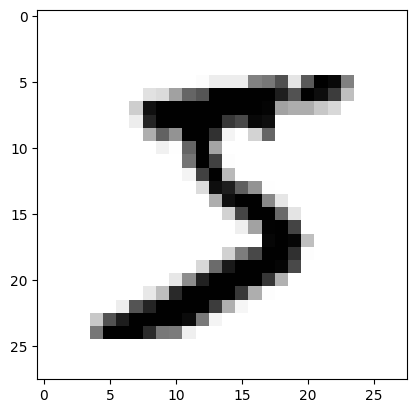

In [22]:
n = 0
plt.imshow(x[n].reshape(28,28), cmap='binary')
print(y[n])
plt.show()

## 3.0 CLASSIFICADOR BINARIO

### 3.1 Separação em treino e teste

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

### 3.2 Treinamento do modelo

In [18]:
sgd_clf = SGDClassifier()
sgd_clf.fit(x_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


### 3.3 Predição

2


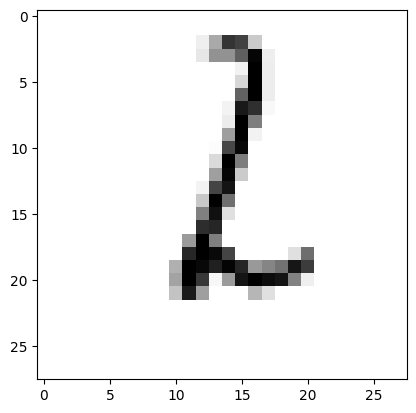

In [35]:
n = 4
plt.imshow(x_train[n].reshape(28,28), cmap='binary')
print(y_train[n])
plt.show()

### 3.4 Score

In [50]:
cross_val_score(sgd_clf, x_train, y_train, cv=3, scoring="accuracy")

array([0.88086201, 0.85152758, 0.88667116])

### 3.5 Matriz de confusão

<Axes: >

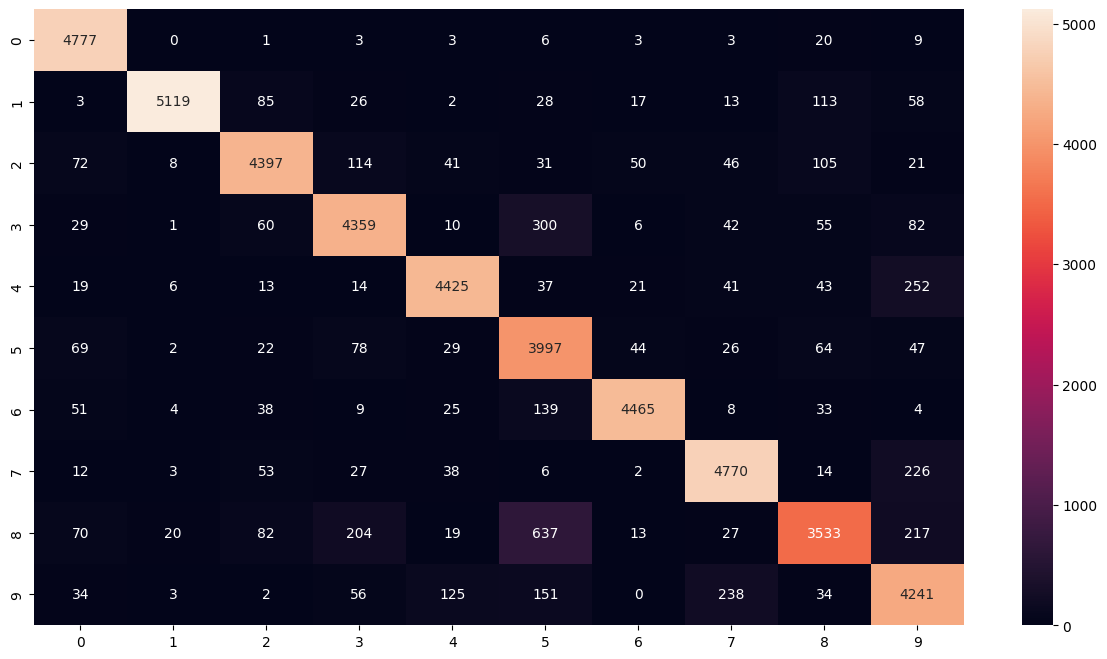

In [55]:
fig, ax = plt.subplots(figsize=(15,8))
conf_mx = confusion_matrix(y_train, sgd_clf.predict(x_train))
sns.heatmap(conf_mx, annot=True, fmt = ".0f")

### 3.6 Precisão e Recall

In [46]:
y_train_pred = sgd_clf.predict(x_train)
print(precision_score(y_train, y_train_pred, average="macro"))
print(recall_score(y_train, y_train_pred, average="macro"))
print(classification_report(y_train, y_train_pred))

0.900886791228291
0.8992045700773975
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4825
           1       0.99      0.94      0.96      5464
           2       0.93      0.90      0.91      4885
           3       0.89      0.88      0.89      4944
           4       0.94      0.91      0.92      4871
           5       0.75      0.91      0.82      4378
           6       0.97      0.93      0.95      4776
           7       0.91      0.93      0.92      5151
           8       0.88      0.73      0.80      4822
           9       0.82      0.87      0.84      4884

    accuracy                           0.90     49000
   macro avg       0.90      0.90      0.90     49000
weighted avg       0.90      0.90      0.90     49000

